# 14. スイッチの『頻度』で表現型のばらつきを操る — FABMOS

> **出典**: Hung M, Chang E, Hussein R, et al. (2014) *Modulating the frequency and bias of stochastic switching to control phenotypic variation.* Nat Commun 5:4574.

シリーズの締めは、**唯一の確率論（Gillespie）**。細胞は遺伝子の OFF/ON 状態を確率的に行き来し、ON のときだけ
タンパク質を作る。FABMOS（**F**requency **A**nd **B**ias **MO**dulation of **S**witching）の発見:

> **平均発現を保ったまま「スイッチ頻度」だけを変えると、集団の分布が
> bimodal（低頻度: OFF 群と ON 群に二峰）↔ unimodal（高頻度: 中央に一峰）を行き来する。**

直感: スイッチが**遅い**と各細胞は OFF か ON に長く留まり、タンパク質が 0 か最大に振り切れる → **二峰**。
スイッチが**速い**と留まる暇なく入れ替わり、タンパク質は時間平均されて中央に集まる → **一峰**。

## モデル（遺伝子1コピー: $G_{off}+G_{on}=1$）

| 反応 | 意味 |
|---|---|
| $G_{off}\to G_{on}\ (k_{on}),\ \ G_{on}\to G_{off}\ (k_{off})$ | 確率的スイッチ |
| $G_{on}\to G_{on}+P\ (s)$ | ON でのみ産生 |
| $P\to\varnothing\ (d)$ | 分解 |

**bias** $=k_{on}/k_{off}$ を固定（平均を一定に保つ）。**頻度** $f$ は $k_{on},k_{off}$ を一律に倍する。
各細胞 = 1本の **Gillespie 軌道**。多数の細胞の終端 $P$ でヒストグラムを作る。

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species

Goff, Gon, P = (Species(x) for x in ['Goff','Gon','P'])
S_PROD, D_DEG = 50.0, 1.0    # ON定常 = s/d = 50, タンパク質寿命 = 1
SP = ['Goff','Gon','P']
def R(a,b,k): return ReactionRule(a,b,k)

def build(f, bias=1.0):
    k_off = f; k_on = f*bias      # bias=1 で ON割合0.5, 平均25
    mdl = NetworkModel()
    for x in [R([Goff],[Gon],k_on), R([Gon],[Goff],k_off), R([Gon],[Gon,P],S_PROD), R([P],[],D_DEG)]:
        mdl.add_reaction_rule(x)
    return mdl

def population(f, n=300, t_end=30.0):
    vals = np.empty(n)
    for i in range(n):
        y0 = {'Goff':1} if i % 2 == 0 else {'Gon':1}   # 初期偏りを回避
        a = run_simulation(t_end, y0=y0, model=build(f), solver='gillespie', ndiv=1, species_list=SP, rndseed=i)
        vals[i] = a.as_array()[-1][3]
    return vals
print('ready')

ready


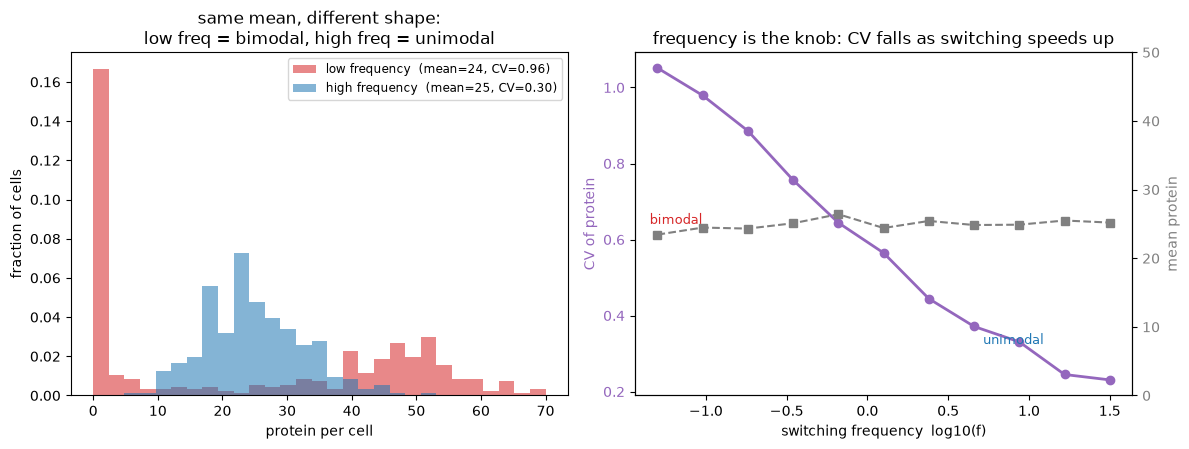

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

bins = np.linspace(0, 70, 30)
for f, c, lab in [(0.1,'C3','low frequency'), (10.0,'C0','high frequency')]:
    v = population(f, n=400)
    ax1.hist(v, bins=bins, alpha=0.55, color=c, density=True,
             label=f'{lab}  (mean={v.mean():.0f}, CV={v.std()/v.mean():.2f})')
ax1.set_xlabel('protein per cell'); ax1.set_ylabel('fraction of cells')
ax1.set_title('same mean, different shape:\nlow freq = bimodal, high freq = unimodal'); ax1.legend(fontsize=8.5)

f_grid = np.logspace(-1.3, 1.5, 11)
means, cvs = [], []
for f in f_grid:
    v = population(f, n=250); means.append(v.mean()); cvs.append(v.std()/v.mean())
ax2.plot(np.log10(f_grid), cvs, 'o-', color='C4', lw=2)
ax2.set_xlabel('switching frequency  log10(f)'); ax2.set_ylabel('CV of protein', color='C4')
ax2.tick_params(axis='y', labelcolor='C4')
ax2.set_title('frequency is the knob: CV falls as switching speeds up')
ax2b = ax2.twinx(); ax2b.plot(np.log10(f_grid), means, 's--', color='gray', lw=1.5)
ax2b.set_ylabel('mean protein', color='gray'); ax2b.set_ylim(0,50); ax2b.tick_params(axis='y', labelcolor='gray')
ax2.text(0.03,0.5,'bimodal', transform=ax2.transAxes, color='C3', fontsize=9)
ax2.text(0.7,0.15,'unimodal', transform=ax2.transAxes, color='C0', fontsize=9)
plt.tight_layout(); plt.show()

## 読み取り

- **左**: 低頻度（赤）は **bimodal**——多くの細胞が 0 付近（OFF）、一部が高発現（ON）に振り切れて二峰。
  高頻度（青）は **unimodal**——中央に一峰。**平均はほぼ同じ（~24）なのに、分布の形がまるで違う。**
- **右**: 頻度を上げると **CV（ばらつき）が単調に下がる**（~1.0 → ~0.25）が、**平均は一定**（灰の破線）。
  頻度が「表現型のばらつきだけを動かすツマミ」になっている（論文 Fig.2d）。

**なぜ重要か**: 集団のばらつき（bet-hedging）は、抗生物質への persister や、環境変動への適応戦略を左右する。
普通の遺伝子制御では「平均を上げるとばらつきも変わる」と絡み合うが、FABMOS は **平均とばらつきを独立に**設計できる。

**シリーズ全体との関係**: 01 で決定論 vs 確率論を見て、02 で閾値のノイズを見た。14 はその確率論の到達点——
**ノイズは邪魔者ではなく、細胞が積極的に制御する『表現型の資源』**だという視点。

## 発展課題（自作）

1. **bias** を動かす（`bias`≠1）と、平均（ON 割合）と分布はどう変わる？ 頻度（ばらつき）と bias（平均）を独立に操れることを確認。
2. タンパク質寿命 `D_DEG` を変えると、bimodal/unimodal の境目の頻度がどう動く？（鍵はスイッチ速度と分解速度の比）
3. 1細胞の時系列 $P(t)$ を数本描き、低頻度で 0↔50 を行き来（矩形波的）、高頻度で中央を小刻みに揺れる様子を可視化する。
4. [[bio-a_hfq-phylogenetics]] との接続: Hfq/sRNA 回路も細胞間ばらつきを生む（02 の閾値ノイズ）。
   sRNA 制御を「スイッチ」と見立て、その頻度・biasが表現型多様性にどう効くかを、進化の観点で考える。